# PyTorch MLP for binary tabular classification
This notebook demonstrates training and saved-model inference on a 200-row synthetic CSV.
A stratified 60/20/20 split separates training, validation and test observations. The scaler is
fitted on training rows only. Validation loss chooses the checkpoint; the test set is evaluated
only after selection. The demonstration does not establish performance on real-world data.

In [1]:
from pathlib import Path
import sys

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/model.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from within its repository folder.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import random
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from src.data_utils import CSVDataset, batch_size_without_singleton
from src.model import MLP, predict_from_checkpoint

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
# CPU keeps this small demonstration portable; GPU execution is not validated here.
device = torch.device('cpu')
features = [f'f{i}' for i in range(1, 11)]
dataset = CSVDataset(ROOT / 'data/sample.csv', features, 'label')
raw_X, y = dataset.X.numpy(), dataset.y.numpy()
development, test_rows = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=SEED)
train_rows, val_rows = train_test_split(development, test_size=0.25, stratify=y[development], random_state=SEED)
assert not (set(train_rows) & set(val_rows) or set(train_rows) & set(test_rows) or set(val_rows) & set(test_rows))
scaler = StandardScaler().fit(raw_X[train_rows])

def tensors(rows):
    return TensorDataset(torch.tensor(scaler.transform(raw_X[rows]), dtype=torch.float32),
                         torch.tensor(y[rows], dtype=torch.long))

batch_size = batch_size_without_singleton(len(train_rows), 32)
train_loader = DataLoader(tensors(train_rows), batch_size=batch_size, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(tensors(val_rows), batch_size=64)
test_loader = DataLoader(tensors(test_rows), batch_size=64)
print(f'Train: {len(train_rows)}; validation: {len(val_rows)}; test: {len(test_rows)}')
model = MLP(len(features)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

Train: 120; validation: 40; test: 40


Completed 56 epochs. Restored epoch 46; validation loss: 0.1728


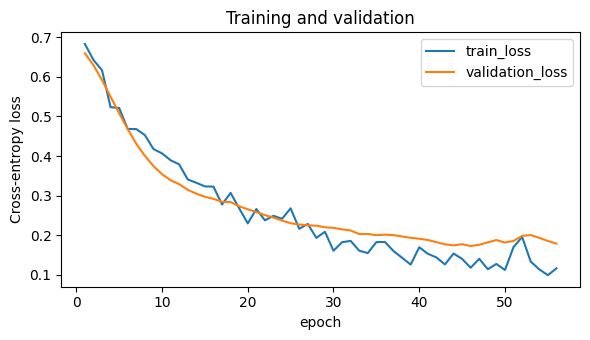

In [3]:
def evaluate(loader):
    model.eval()
    losses, probabilities, labels = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            losses += criterion(logits, yb.to(device)).item() * len(xb)
            probabilities.append(logits.softmax(dim=1).cpu().numpy())
            labels.append(yb.numpy())
    return losses / len(loader.dataset), np.concatenate(probabilities), np.concatenate(labels)

history = []
best_loss, stale = float('inf'), 0
best_state = None
for epoch in range(1, 101):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb.to(device)), yb.to(device))
        loss.backward(); optimizer.step()
        train_loss += loss.item() * len(xb)
    val_loss, val_probabilities, val_labels = evaluate(val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss / len(train_rows),
                    'validation_loss': val_loss,
                    'validation_accuracy': accuracy_score(val_labels, val_probabilities.argmax(axis=1))})
    if val_loss < best_loss - 1e-5:
        best_loss, best_epoch, stale = val_loss, epoch, 0
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
    else:
        stale += 1
    if stale >= 10:
        break
model.load_state_dict(best_state)
restored_loss, _, _ = evaluate(val_loader)
np.testing.assert_allclose(restored_loss, best_loss, atol=1e-7)
print(f'Completed {epoch} epochs. Restored epoch {best_epoch}; validation loss: {restored_loss:.4f}')
history_frame = pd.DataFrame(history)
history_frame.plot(x='epoch', y=['train_loss', 'validation_loss'], figsize=(6, 3.5))
plt.ylabel('Cross-entropy loss'); plt.title('Training and validation'); plt.tight_layout(); plt.show()

In [4]:
# Fresh forward passes from the RESTORED model; no stale last-epoch predictions.
test_loss, test_probabilities, test_labels = evaluate(test_loader)
test_predictions = test_probabilities.argmax(axis=1)
print(f'Synthetic held-out test loss: {test_loss:.4f}')
print(classification_report(test_labels, test_predictions, labels=[0, 1], zero_division=0))
print('Confusion matrix (rows: true, columns: predicted):')
print(confusion_matrix(test_labels, test_predictions, labels=[0, 1]))

Synthetic held-out test loss: 0.2661
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       0.90      0.90      0.90        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40

Confusion matrix (rows: true, columns: predicted):
[[18  2]
 [ 2 18]]


In [5]:
# Store model, feature order, preprocessing, selected epoch and split membership together.
output_dir = ROOT / 'outputs'
output_dir.mkdir(exist_ok=True)
checkpoint_path = output_dir / 'mlp_demo.pt'
torch.save({'state_dict': best_state, 'feature_columns': features,
            'hidden': [64, 32], 'dropout': 0.2,
            'scaler_mean': scaler.mean_.tolist(), 'scaler_scale': scaler.scale_.tolist(),
            'best_epoch': best_epoch, 'validation_loss': best_loss, 'seed': SEED,
            'train_rows': train_rows.tolist(), 'validation_rows': val_rows.tolist(),
            'test_rows': test_rows.tolist()}, checkpoint_path)
raw_frame = pd.DataFrame(raw_X[test_rows], columns=features)
restored_probabilities = predict_from_checkpoint(checkpoint_path, raw_frame)
np.testing.assert_allclose(restored_probabilities, test_probabilities, atol=1e-6, rtol=1e-6)
history_frame.to_csv(output_dir / 'training_history.csv', index=False)
print('Saved outputs/mlp_demo.pt and training_history.csv.')
print('Reloaded model and training scaler reproduce the held-out probabilities.')

Saved outputs/mlp_demo.pt and training_history.csv.
Reloaded model and training scaler reproduce the held-out probabilities.


The checkpoint file is generated locally and is excluded from version control. Rerunning the demo
overwrites these two output files. For a new dataset, set the CSV path and feature columns explicitly;
missing values and labels other than 0/1 are rejected. This example assumes independent rows.
Grouped or time-dependent data require a different split strategy.